# GNN Spatial Électrique — Prédiction 1h

Prédit `p` (production agrégée par bus générateur) sur **l'heure suivante**  
à partir des **72 heures d'historique** et de la **structure spatiale du réseau HT belge**.

- **Modèle** : encodeur MLP → message passing GINEConv → décodeur MLP  
- **45 bus**, **65 lignes**, **24 générateurs** → **15 bus générateurs**  
- **Fenêtres** : 72 h d'entrée, 1 h de cible, glissement de 24 h en 24 h

In [2]:
# ============================================================
# Cellule 1 - Installation / vérification de PyTorch Geometric
# ============================================================
import sys
import subprocess
import pkgutil

def ensure_package(pkg_name: str, pip_name: str | None = None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installation de {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name,
                               "--quiet", "--no-warn-script-location"])
        print(f"{name} installé.")
    else:
        print(f"{pkg_name} déjà disponible.")

ensure_package("torch_geometric", "torch-geometric")

import torch_geometric
print("torch_geometric version:", torch_geometric.__version__)


torch_geometric déjà disponible.


C:\Users\yoans\anaconda3\envs\torch118\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch_geometric version: 2.7.0


In [123]:
# ============================================================
# Cellule 2 - Hyperparamètres / constantes / chemins
# ============================================================
from pathlib import Path

CONFIG = {
    # ── chemins ───────────────────────────────────────────────────
    "BASE_DIR"      : Path("."),
    "PATH_NETWORK"  : Path("./Elec Network Data.xlsx"),
    "PATH_WIND"     : Path("./input/Wind Data.xlsx"),
    "PATH_LOAD"     : Path("./input/Elec Load Data.xlsx"),
    "PATH_DECISION" : Path("./output/Decision_variablesRU.xlsx"),

    # ── structure problème ────────────────────────────────────────
    "MONTHS"   : [f"{m:02d}" for m in range(1, 13)],
    "NUM_NODES": 45,
    "GENERATOR_BUS_IDX": [6, 12, 14, 15, 18, 26, 27, 28, 32, 35, 37, 39, 41, 43, 44],
    "NUM_GENERATORS": 24,

    # ── fenêtres temporelles ──────────────────────────────────────
    # HORIZON = 1 heure  |  STRIDE = 24 h (glissement journalier)
    "HIST_HOURS"    : 72,
    "HORIZON_HOURS" : 1,
    "STRIDE_HOURS"  : 24,

    # ── split temporel ────────────────────────────────────────────
    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END"  : "2024-11-01 00:00:00",

    # ── features dynamiques nodales ───────────────────────────────
    "USE_LOAD_HISTORY"         : True,
    "USE_WIND_OFFSHORE_HISTORY": True,
    "USE_WIND_ONSHORE_HISTORY" : True,
    "USE_P_HISTORY"            : False,

    # ── features statiques nodales ────────────────────────────────
    "USE_NODE_STATIC_IS_GENERATOR"   : True,
    "USE_NODE_STATIC_GENERATOR_COUNT": True,
    "USE_NODE_STATIC_PMAX_TOTAL"     : True,
    "USE_NODE_STATIC_LOAD_SHARE"     : True,
    "USE_NODE_STATIC_PV_SHARE"       : True,
    "USE_NODE_STATIC_ONSHORE_SHARE"  : True,
    "USE_NODE_STATIC_IS_OFFSHORE"    : True,
    "USE_NODE_STATIC_IS_IMPORT"      : True,
    "USE_NODE_STATIC_IMPORT_PMAX"    : True,
    "USE_NODE_STATIC_VOLTAGE_KV"     : True,
    "USE_NODE_STATIC_IS_TRANSFER"    : True,
    "USE_NODE_STATIC_DEGREE"         : True,

    # ── features statiques d'arête ────────────────────────────────
    "EDGE_STATIC_COLUMNS": [
        "X_pu", "b_pu", "Pmax_MW", "Length_km", "Inom_A", "UB_kV",
    ],
    "USE_BIDIRECTIONAL_EDGES": True,

    # ── modèle ────────────────────────────────────────────────────
    "MODEL_TYPE"          : "gine",
    "HIDDEN_DIM"          : 128,
    "ENCODER_HIDDEN_DIMS" : [256, 128],
    "DECODER_HIDDEN_DIMS" : [256, 128],
    "NUM_MP_LAYERS"       : 3,
    "DROPOUT"             : 0.1,
    "USE_BATCHNORM"       : True,
    "RESIDUAL"            : True,

    # ── entraînement ──────────────────────────────────────────────
    "SEED"                    : 42,
    "DEVICE"                  : "cpu",
    "EPOCHS"                  : 200,
    "BATCH_SIZE"              : 24,
    "LR"                      : 5e-4,
    "WEIGHT_DECAY"            : 1e-4,
    "GRAD_CLIP_NORM"          : 2.0,
    "EARLY_STOPPING_PATIENCE" : 30,
    "EARLY_STOPPING_MIN_DELTA": 1e-4,
    "SCHEDULER_FACTOR"        : 0.4,
    "SCHEDULER_PATIENCE"      : 6,
    "SCHEDULER_MIN_LR"        : 1e-6,

    # ── divers ────────────────────────────────────────────────────
    "PERSISTENCE_MODE" : "same_hour_yesterday",   # valeur 24h avant la cible
    "SAVE_MODEL_STATE" : False,
    "MODEL_STATE_PATH" : Path("spatial_elec_gnn_1h.pt"),
}

PATHS = {
    "network" : CONFIG["BASE_DIR"] / CONFIG["PATH_NETWORK"],
    "wind"    : CONFIG["BASE_DIR"] / CONFIG["PATH_WIND"],
    "load"    : CONFIG["BASE_DIR"] / CONFIG["PATH_LOAD"],
    "decision": CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

print("Fichiers attendus :")
for k, v in PATHS.items():
    print(f"  {k}: {v.resolve()} | exists={v.exists()}")
for p in PATHS.values():
    assert p.exists(), f"Fichier introuvable: {p}"
print("\nCONFIG OK.")


Fichiers attendus :
  network: C:\Users\yoans\TFE - GAZ\Elec Network Data.xlsx | exists=True
  wind: C:\Users\yoans\TFE - GAZ\input\Wind Data.xlsx | exists=True
  load: C:\Users\yoans\TFE - GAZ\input\Elec Load Data.xlsx | exists=True
  decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True

CONFIG OK.


In [124]:
# ============================================================
# Cellule 3 - Imports, seed, utilitaires de base
# ============================================================
import copy
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, NNConv

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

DEVICE = torch.device(
    "cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu"
)
print("DEVICE =", DEVICE)

def pretty_shape(name, x):
    if isinstance(x, (np.ndarray, torch.Tensor, pd.DataFrame, pd.Series)):
        print(f"{name}: shape={getattr(x, 'shape', None)}")
    else:
        print(f"{name}: type={type(x)}")

def drop_unnamed_first_col(df: pd.DataFrame) -> pd.DataFrame:
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        return df.drop(columns=[df.columns[0]])
    return df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


DEVICE = cpu


In [125]:
# ============================================================
# Cellule 4 - Lecture des données statiques du réseau électrique
# ============================================================
buses_df    = pd.read_excel(PATHS["network"], sheet_name="Buses")
lines_df    = pd.read_excel(PATHS["network"], sheet_name="LinesMerged")
gen_df      = pd.read_excel(PATHS["network"], sheet_name="Gen")
genmap_df   = pd.read_excel(PATHS["network"], sheet_name="GenMap", header=0)
windmap_df  = pd.read_excel(PATHS["network"], sheet_name="WindMap", header=0)
impmap_df   = pd.read_excel(PATHS["network"], sheet_name="ImpMap", header=0)
imp_df      = pd.read_excel(PATHS["network"], sheet_name="Imp")
renew_df    = pd.read_excel(PATHS["network"], sheet_name="Renew")

num_nodes = CONFIG["NUM_NODES"]

pretty_shape("buses_df",   buses_df)
pretty_shape("lines_df",   lines_df)
pretty_shape("gen_df",     gen_df)
pretty_shape("genmap_df",  genmap_df)
pretty_shape("windmap_df", windmap_df)
pretty_shape("impmap_df",  impmap_df)

assert len(buses_df) == num_nodes
assert len(gen_df)   == CONFIG["NUM_GENERATORS"]
assert genmap_df.shape == (num_nodes, CONFIG["NUM_GENERATORS"])
assert windmap_df.shape[0] == num_nodes
print("Données statiques réseau chargées.")


buses_df: shape=(45, 9)
lines_df: shape=(65, 18)
gen_df: shape=(24, 14)
genmap_df: shape=(45, 24)
windmap_df: shape=(45, 1)
impmap_df: shape=(45, 8)
Données statiques réseau chargées.


In [126]:
# ============================================================
# Cellule 5 - Mapping générateur → bus + Pmax par bus
# ============================================================
genmap = genmap_df.to_numpy(dtype=float)   # [45, 24]

generator_to_bus = {}
for gen_idx in range(CONFIG["NUM_GENERATORS"]):
    connected_buses = np.where(genmap[:, gen_idx] > 0.5)[0]
    assert len(connected_buses) == 1, f"Gen {gen_idx} → {len(connected_buses)} bus"
    generator_to_bus[gen_idx] = int(connected_buses[0])

pmax_per_bus = np.zeros(num_nodes, dtype=float)
for gen_idx, bus_idx in generator_to_bus.items():
    pmax_val = gen_df.iloc[gen_idx]["Pmax_MW"]
    if isinstance(pmax_val, str):
        pmax_val = eval(pmax_val.replace("=", ""))
    pmax_per_bus[bus_idx] += float(pmax_val)

gen_count_per_bus = np.zeros(num_nodes, dtype=int)
for gen_idx, bus_idx in generator_to_bus.items():
    gen_count_per_bus[bus_idx] += 1

gen_buses_from_map = sorted(set(generator_to_bus.values()))
assert gen_buses_from_map == sorted(CONFIG["GENERATOR_BUS_IDX"])
print(f"{len(gen_buses_from_map)} bus générateurs (0-based): {gen_buses_from_map}")

windmap       = windmap_df.to_numpy(dtype=float).flatten()
offshore_bus_idx = np.where(windmap > 0.5)[0]
assert len(offshore_bus_idx) == 1 and offshore_bus_idx[0] == 38

impmap = impmap_df.to_numpy(dtype=float)
is_import_bus  = (impmap.sum(axis=1) > 0).astype(float)
import_pmax_mw = np.zeros(num_nodes, dtype=float)
for i in range(num_nodes):
    for j in range(8):
        if impmap[i, j] > 0.5:
            import_pmax_mw[i] += float(imp_df.iloc[j]["Pmax_MW"])

print("Mapping OK.")


15 bus générateurs (0-based): [6, 12, 14, 15, 18, 26, 27, 28, 32, 35, 37, 39, 41, 43, 44]
Mapping OK.


In [127]:
# ============================================================
# Cellule 6 - Recalcul des shares nodaux
# ============================================================
transfos   = buses_df["Transfos"].to_numpy(dtype=float)
load_share = transfos / transfos.sum()
assert np.isclose(load_share.sum(), 1.0)

PV_SHARES_RAW = {
    1: 3.455/2,  2: 2.192/4,  4: 16.02/2,  5: 7.093/11,
    7: 15.46/3,  8: 7.093/11, 10: 3.455/2, 13: 17.37/4,
   14: 17.37/4, 16: 7.625/2, 17: 7.093/11, 19: 16.02/2,
   20: 7.093/11, 21: 17.26/4, 22: 7.093/11, 23: 7.093/11,
   25: 2.192/4, 26: 17.26/4, 27: 17.26/4,  28: 15.46/3,
   29: 17.37/4, 31: 7.093/11, 32: 7.093/11, 33: 17.37/4,
   34: 7.093/11, 35: 2.192/4, 36: 7.093/11, 38: 7.625/2,
   40: 7.093/11, 42: 15.46/3, 43: 2.192/4, 44: 17.26/4, 45: 13.52,
}
ONSHORE_SHARES_RAW = {
    1: 11.599/2,  2: 3.459/4,  4: 8.741/2,  5: 9.825/11,
    7: 5.15/3,   8: 9.825/11, 10: 11.599/2, 13: 18.252/4,
   14: 18.252/4, 16: 17.785/2, 17: 9.825/11, 19: 8.741/2,
   20: 9.825/11, 21: 14.835/4, 22: 9.825/11, 23: 9.825/11,
   25: 3.459/4,  26: 14.835/4, 27: 14.835/4, 28: 5.15/3,
   29: 18.252/4, 31: 9.825/11, 32: 9.825/11, 33: 18.252/4,
   34: 9.825/11, 35: 3.459/4,  36: 9.825/11, 38: 17.785/2,
   40: 9.825/11, 42: 5.15/3,  43: 3.459/4,  44: 14.835/4, 45: 10.35,
}

pv_share      = np.array([PV_SHARES_RAW.get(i+1, 0.0)      for i in range(num_nodes)], dtype=float)
onshore_share = np.array([ONSHORE_SHARES_RAW.get(i+1, 0.0) for i in range(num_nodes)], dtype=float)

pv_share_norm      = pv_share / (pv_share.sum() + 1e-12)
onshore_share_norm = onshore_share / (onshore_share.sum() + 1e-12)

print("load_share.sum()   =", load_share.sum())
print("pv_share.sum()     =", pv_share.sum())
print("onshore_share.sum()=", onshore_share.sum())


load_share.sum()   = 1.0
pv_share.sum()     = 99.995
onshore_share.sum()= 99.99599999999998


In [128]:
# ============================================================
# Cellule 7 - Helpers de lecture des séries temporelles 2024
# ============================================================
def read_decision_p(months, decision_path: Path):
    """Retourne p_full [T, 24] et ts_p [T]."""
    all_arrays = []
    for m in months:
        sheet = f"p-{m}-2024"
        df = pd.read_excel(decision_path, sheet_name=sheet, header=0, index_col=0)
        all_arrays.append(df.to_numpy(dtype=float))
    p_full = np.concatenate(all_arrays, axis=0)
    ts_p = pd.date_range("2024-01-01", periods=len(p_full), freq="h")
    return p_full, ts_p

def read_elec_load(months, load_path: Path):
    """Retourne load_total [T] (MW) et ts_load [T]."""
    dfs = []
    for m in months:
        df = pd.read_excel(load_path, sheet_name=f"{m}-2024", header=0, usecols=[0, 1])
        df.columns = ["datetime", "load_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df)
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["load_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])

def read_wind(months, wind_path: Path):
    """Retourne wind_total [T] (MW) et ts_wind [T]."""
    dfs = []
    for m in months:
        df = pd.read_excel(wind_path, sheet_name=f"{m}-2024", header=0, usecols=[0, 1])
        df.columns = ["datetime", "wind_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df)
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["wind_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])


In [129]:
# ============================================================
# Cellule 8 - Lecture et concaténation des séries 2024
# ============================================================
MONTHS = CONFIG["MONTHS"]

p_full,     ts_p    = read_decision_p(MONTHS, PATHS["decision"])
load_total, ts_load = read_elec_load(MONTHS, PATHS["load"])
wind_total, ts_wind = read_wind(MONTHS, PATHS["wind"])

assert len(ts_p) == len(ts_load) == len(ts_wind)
assert p_full.shape[1] == 24

print("Plage temporelle    :", ts_p.min(), "->", ts_p.max())
print("Nombre total d'heures:", len(ts_p))
pretty_shape("p_full [T, 24]", p_full)
pretty_shape("load_total [T]", load_total)
pretty_shape("wind_total [T]", wind_total)


Plage temporelle    : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Nombre total d'heures: 8784
p_full [T, 24]: shape=(8784, 24)
load_total [T]: shape=(8784,)
wind_total [T]: shape=(8784,)


In [130]:
# ============================================================
# Cellule 9 - Agrégation de p par bus + distribution load/wind
# ============================================================
T = len(ts_p)

p_bus_full = np.zeros((T, num_nodes), dtype=float)
for gen_idx, bus_idx in generator_to_bus.items():
    p_bus_full[:, bus_idx] += p_full[:, gen_idx]

p_bus_generator = p_bus_full[:, CONFIG["GENERATOR_BUS_IDX"]]   # [T, 15]

np.testing.assert_allclose(
    p_bus_full.sum(axis=1), p_full.sum(axis=1), rtol=1e-6
)
print("Agrégation p par bus OK.")

load_nodal          = load_total[:, None] * load_share[None, :]
wind_offshore_nodal = np.zeros((T, num_nodes), dtype=float)
wind_offshore_nodal[:, 38] = wind_total
wind_onshore_nodal  = wind_total[:, None] * onshore_share_norm[None, :]
p_history_nodal     = p_bus_full.copy()

pretty_shape("p_bus_generator [T, 15]", p_bus_generator)
pretty_shape("load_nodal [T, 45]", load_nodal)


Agrégation p par bus OK.
p_bus_generator [T, 15]: shape=(8784, 15)
load_nodal [T, 45]: shape=(8784, 45)


In [131]:
# ============================================================
# Cellule 10 - Construction du tenseur dynamique nodal [T, N, F_dyn]
# ============================================================
dyn_feature_dict = {}

if CONFIG["USE_LOAD_HISTORY"]:
    dyn_feature_dict["load_nodal"]     = load_nodal
if CONFIG["USE_WIND_OFFSHORE_HISTORY"]:
    dyn_feature_dict["wind_offshore"]  = wind_offshore_nodal
if CONFIG["USE_WIND_ONSHORE_HISTORY"]:
    dyn_feature_dict["wind_onshore"]   = wind_onshore_nodal
if CONFIG["USE_P_HISTORY"]:
    dyn_feature_dict["p_history"]      = p_history_nodal

dyn_feature_names = list(dyn_feature_dict.keys())
assert len(dyn_feature_names) > 0

dyn_tensor = np.stack([dyn_feature_dict[k] for k in dyn_feature_names], axis=-1)

print("Features dynamiques:", dyn_feature_names)
pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)


Features dynamiques: ['load_nodal', 'wind_offshore', 'wind_onshore']
dyn_tensor [T, N, F_dyn]: shape=(8784, 45, 3)


In [132]:
# ============================================================
# Cellule 11 - Features statiques nodales [N, F_static]
# ============================================================
degrees = np.zeros(num_nodes, dtype=float)
for _, row in lines_df.iterrows():
    u = int(row["FromNode"]) - 1
    v = int(row["ToNode"])   - 1
    degrees[u] += 1
    degrees[v] += 1

is_transfer = (buses_df["Type"] == "Transfer").to_numpy(dtype=float)
voltage_kv  = buses_df["UB_kV"].to_numpy(dtype=float)

node_static_parts = []
node_static_names = []

if CONFIG["USE_NODE_STATIC_IS_GENERATOR"]:
    node_static_parts.append((gen_count_per_bus > 0).astype(float)[:, None])
    node_static_names.append("is_generator")
if CONFIG["USE_NODE_STATIC_GENERATOR_COUNT"]:
    node_static_parts.append(gen_count_per_bus[:, None].astype(float))
    node_static_names.append("generator_count")
if CONFIG["USE_NODE_STATIC_PMAX_TOTAL"]:
    node_static_parts.append(pmax_per_bus[:, None])
    node_static_names.append("pmax_total_MW")
if CONFIG["USE_NODE_STATIC_LOAD_SHARE"]:
    node_static_parts.append(load_share[:, None])
    node_static_names.append("load_share")
if CONFIG["USE_NODE_STATIC_PV_SHARE"]:
    node_static_parts.append(pv_share_norm[:, None])
    node_static_names.append("pv_share")
if CONFIG["USE_NODE_STATIC_ONSHORE_SHARE"]:
    node_static_parts.append(onshore_share_norm[:, None])
    node_static_names.append("onshore_share")
if CONFIG["USE_NODE_STATIC_IS_OFFSHORE"]:
    node_static_parts.append(windmap[:, None])
    node_static_names.append("is_offshore_wind")
if CONFIG["USE_NODE_STATIC_IS_IMPORT"]:
    node_static_parts.append(is_import_bus[:, None])
    node_static_names.append("is_import_bus")
if CONFIG["USE_NODE_STATIC_IMPORT_PMAX"]:
    node_static_parts.append(import_pmax_mw[:, None])
    node_static_names.append("import_pmax_MW")
if CONFIG["USE_NODE_STATIC_VOLTAGE_KV"]:
    node_static_parts.append(voltage_kv[:, None])
    node_static_names.append("voltage_kV")
if CONFIG["USE_NODE_STATIC_IS_TRANSFER"]:
    node_static_parts.append(is_transfer[:, None])
    node_static_names.append("is_transfer")
if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts.append(degrees[:, None])
    node_static_names.append("degree")

node_static = (
    np.concatenate(node_static_parts, axis=1)
    if node_static_parts
    else np.zeros((num_nodes, 0), dtype=float)
)

print("node_static_names =", node_static_names)
pretty_shape("node_static [N, F_static]", node_static)


node_static_names = ['is_generator', 'generator_count', 'pmax_total_MW', 'load_share', 'pv_share', 'onshore_share', 'is_offshore_wind', 'is_import_bus', 'import_pmax_MW', 'voltage_kV', 'is_transfer', 'degree']
node_static [N, F_static]: shape=(45, 12)


In [133]:
# ============================================================
# Cellule 12 - Edge index + features d'arête statiques
# ============================================================
edge_static_cols = CONFIG["EDGE_STATIC_COLUMNS"]
for col in edge_static_cols:
    assert col in lines_df.columns, f"Colonne arête introuvable: {col}"

edge_static_base = (
    lines_df[edge_static_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .to_numpy(dtype=float)
)

edge_pairs = []
edge_attrs = []
for i, row in lines_df.iterrows():
    u = int(row["FromNode"]) - 1
    v = int(row["ToNode"])   - 1
    ea = edge_static_base[i]
    edge_pairs.append((u, v)); edge_attrs.append(ea)
    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs.append((v, u)); edge_attrs.append(ea.copy())

edge_index    = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw = np.array(edge_attrs, dtype=float)

assert edge_index.shape[0] == 2
assert edge_index.max() < num_nodes
assert edge_attr_raw.shape[0] == edge_index.shape[1]
print("edge_static_cols  =", edge_static_cols)
print("Nb arêtes         =", edge_index.shape[1])
pretty_shape("edge_attr_raw [E, F]", edge_attr_raw)


edge_static_cols  = ['X_pu', 'b_pu', 'Pmax_MW', 'Length_km', 'Inom_A', 'UB_kV']
Nb arêtes         = 130
edge_attr_raw [E, F]: shape=(130, 6)


In [134]:
# ============================================================
# Cellule 13 - Normalisation + génération des indices de fenêtres
# ============================================================
TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_END   = pd.Timestamp(CONFIG["VAL_END"])

HIST = CONFIG["HIST_HOURS"]      # 72
HOR  = CONFIG["HORIZON_HOURS"]   #  1
STR  = CONFIG["STRIDE_HOURS"]    # 24

ts_p = pd.to_datetime(ts_p)

# ── Masques horaires ──────────────────────────────────────
train_time_mask = ts_p < TRAIN_END
val_time_mask   = (ts_p >= TRAIN_END) & (ts_p < VAL_END)
test_time_mask  = ts_p >= VAL_END

print("Heures train/val/test :",
      int(train_time_mask.sum()), "/",
      int(val_time_mask.sum()), "/",
      int(test_time_mask.sum()))

# ── Scalers (fit sur train uniquement) ───────────────────
T, N_nodes, F_dyn = dyn_tensor.shape

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[train_time_mask].reshape(-1, F_dyn))
dyn_tensor_scaled = dyn_scaler.transform(
    dyn_tensor.reshape(-1, F_dyn)
).reshape(T, N_nodes, F_dyn)

node_static_scaler = StandardScaler()
node_static_scaler.fit(node_static)
node_static_scaled = node_static_scaler.transform(node_static)

edge_scaler = StandardScaler()
edge_scaler.fit(edge_attr_raw)
edge_attr_scaled = edge_scaler.transform(edge_attr_raw)

# Scaler cible : 1 scaler pour les N_GEN générateurs
p_bus_gen_train = p_bus_generator[train_time_mask]
target_scaler   = StandardScaler()
target_scaler.fit(p_bus_gen_train)
p_bus_gen_scaled = target_scaler.transform(p_bus_generator)

N_GEN = len(CONFIG["GENERATOR_BUS_IDX"])
print(f"N_GEN = {N_GEN}")
print("target_scaler mean_.shape =", target_scaler.mean_.shape)

# ── Indices de fenêtres glissantes ────────────────────────
# target_start = start + HIST → fenêtre couvre [start, start+HIST-1] + cible à start+HIST
all_start_indices   = np.arange(0, T - HIST - HOR + 1, STR, dtype=int)
target_start_times  = ts_p[all_start_indices + HIST]

train_window_mask = target_start_times < TRAIN_END
val_window_mask   = (target_start_times >= TRAIN_END) & (target_start_times < VAL_END)
test_window_mask  = target_start_times >= VAL_END

print(f"\nFenêtres : {len(all_start_indices)} total | "
      f"train={int(train_window_mask.sum())} | "
      f"val={int(val_window_mask.sum())} | "
      f"test={int(test_window_mask.sum())}")
assert all([train_window_mask.sum(), val_window_mask.sum(), test_window_mask.sum()])


Heures train/val/test : 6576 / 744 / 1464
N_GEN = 15
target_scaler mean_.shape = (15,)

Fenêtres : 363 total | train=271 | val=31 | test=61


In [135]:
# ============================================================
# Cellule 14 - Construction d'une fenêtre glissante
# Entrée  : 72h d'historique → tenseur [45, 72*F_dyn + F_static]
# Cible   : production des 15 bus générateurs sur 1h → [15, 1]
# ============================================================
def build_single_window(start_idx: int):
    hist_slice   = slice(start_idx,        start_idx + HIST)
    target_slice = slice(start_idx + HIST, start_idx + HIST + HOR)

    # [HIST, 45, F_dyn] → [45, HIST, F_dyn] → [45, HIST*F_dyn]
    hist_dyn = dyn_tensor_scaled[hist_slice]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2)).reshape(num_nodes, -1)

    x = np.concatenate([hist_dyn, node_static_scaled], axis=1)

    # y : [N_GEN, HOR] = [15, 1]
    y      = p_bus_gen_scaled[target_slice].T
    y_real = p_bus_generator[target_slice].T

    return {
        "x"               : x.astype(np.float32),
        "y"               : y.astype(np.float32),
        "y_real"          : y_real.astype(np.float32),
        "start_idx"       : np.int64(start_idx),
        "target_start_idx": np.int64(start_idx + HIST),
        "target_end_idx"  : np.int64(start_idx + HIST + HOR - 1),
    }

expected_x_dim = HIST * dyn_tensor.shape[-1] + node_static_scaled.shape[1]

# Vérification sur un échantillon
sample0 = build_single_window(int(all_start_indices[0]))
assert sample0["x"].shape    == (num_nodes, expected_x_dim)
assert sample0["y"].shape    == (N_GEN, HOR),  f"Attendu ({N_GEN},{HOR}), got {sample0['y'].shape}"
assert sample0["y_real"].shape == (N_GEN, HOR)

# Vérification d'alignement
for idx in [all_start_indices[0], all_start_indices[len(all_start_indices)//2], all_start_indices[-1]]:
    s = build_single_window(int(idx))
    ts0, ts1 = int(s["target_start_idx"]), int(s["target_end_idx"])
    assert np.allclose(p_bus_generator[ts0:ts1+1].T, s["y_real"]), "Alignement KO"

print(f"expected_x_dim = {expected_x_dim}")
print(f"y.shape attendu = ({N_GEN}, {HOR})")
print("Alignement OK sur tous les checks.")


expected_x_dim = 228
y.shape attendu = (15, 1)
Alignement OK sur tous les checks.


In [136]:
# ============================================================
# Cellule 15 - Dataset PyG + DataLoaders
# ============================================================
class ElecSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx: int):
        start_idx = int(self.start_indices[idx])
        sample = build_single_window(start_idx)
        data = Data(
            x             = torch.tensor(sample["x"],      dtype=torch.float32),
            edge_index    = edge_index.clone(),
            edge_attr     = torch.tensor(edge_attr_scaled, dtype=torch.float32),
            y             = torch.tensor(sample["y"],      dtype=torch.float32),
            generator_mask= torch.tensor(
                np.isin(np.arange(num_nodes), CONFIG["GENERATOR_BUS_IDX"]),
                dtype=torch.bool),
        )
        data.start_idx         = int(sample["start_idx"])
        data.target_start_idx  = int(sample["target_start_idx"])
        data.target_end_idx    = int(sample["target_end_idx"])
        data.y_real            = torch.tensor(sample["y_real"], dtype=torch.float32)
        return data

train_start_idx = all_start_indices[train_window_mask]
val_start_idx   = all_start_indices[val_window_mask]
test_start_idx  = all_start_indices[test_window_mask]

train_ds = ElecSpatialWindowDataset(train_start_idx)
val_ds   = ElecSpatialWindowDataset(val_start_idx)
test_ds  = ElecSpatialWindowDataset(test_start_idx)

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print(f"len(train_ds)={len(train_ds)} | len(val_ds)={len(val_ds)} | len(test_ds)={len(test_ds)}")

batch = next(iter(train_loader))
assert batch.x.shape[1]         == expected_x_dim
assert batch.edge_attr.shape[1] == edge_attr_scaled.shape[1]
assert batch.y.shape[-1]        == HOR
print("Batch shapes OK.")
pretty_shape("batch.x",   batch.x)
pretty_shape("batch.y",   batch.y)


len(train_ds)=271 | len(val_ds)=31 | len(test_ds)=61
Batch shapes OK.
batch.x: shape=torch.Size([1080, 228])
batch.y: shape=torch.Size([360, 1])


In [137]:
# ============================================================
# Cellule 16 - Bloc MLP utilitaire
# ============================================================
class MLP(nn.Module):
    def __init__(self, dims, dropout=0.0, use_batchnorm=False, activate_last=False):
        super().__init__()
        assert len(dims) >= 2
        self.dims        = list(dims)
        self.in_channels  = self.dims[0]
        self.out_channels = self.dims[-1]

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            is_last = (i == len(dims) - 2)
            if not is_last or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(dims[i + 1]))
                layers.append(nn.ReLU())
                if dropout > 0.0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [138]:
# ============================================================
# Cellule 17 - Modèle GNN spatial (SpatialElecGNN)
# Encodeur MLP → message passing GINEConv → décodeur MLP
# Sortie : [B * N_GEN, HOR]  avec HOR = 1
# ============================================================
class SpatialElecGNN(nn.Module):
    def __init__(
        self, in_dim, edge_dim, hidden_dim, horizon,
        model_type="gine", encoder_hidden_dims=(256, 128),
        decoder_hidden_dims=(128, 64), num_mp_layers=3,
        dropout=0.0, use_batchnorm=True, residual=True,
    ):
        super().__init__()
        self.model_type    = model_type.lower()
        self.hidden_dim    = hidden_dim
        self.horizon       = horizon
        self.num_mp_layers = num_mp_layers
        self.residual      = residual

        enc_dims = [in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_mp_layers):
            if self.model_type == "nnconv":
                edge_net = MLP([edge_dim, hidden_dim, hidden_dim * hidden_dim],
                               dropout=dropout, use_batchnorm=False, activate_last=False)
                conv = NNConv(hidden_dim, hidden_dim, nn=edge_net, aggr="mean")
            elif self.model_type == "gine":
                nn_mlp = MLP([hidden_dim, hidden_dim, hidden_dim],
                              dropout=dropout, use_batchnorm=False, activate_last=False)
                nn_mlp.in_channels = hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=edge_dim)
            else:
                raise ValueError(f"MODEL_TYPE inconnu: {model_type}")
            self.convs.append(conv)
            self.norms.append(nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity())

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr, generator_mask):
        h = self.encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h    = conv(h, edge_index, edge_attr)
            h    = norm(h)
            h    = F.relu(h)
            if self.residual:
                h = h + h_in
        h_gen = h[generator_mask]          # [B*15, hidden_dim]
        return self.decoder(h_gen)         # [B*15, HOR]


# Test forward rapide
_model_tmp = SpatialElecGNN(
    in_dim=expected_x_dim, edge_dim=edge_attr_scaled.shape[1],
    hidden_dim=CONFIG["HIDDEN_DIM"], horizon=HOR,
    model_type=CONFIG["MODEL_TYPE"],
    encoder_hidden_dims=CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims=CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers=CONFIG["NUM_MP_LAYERS"],
    dropout=CONFIG["DROPOUT"], use_batchnorm=CONFIG["USE_BATCHNORM"],
    residual=CONFIG["RESIDUAL"],
).to(DEVICE)

_batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    _pred = _model_tmp(_batch.x, _batch.edge_index, _batch.edge_attr, _batch.generator_mask)
assert _pred.shape == _batch.y.view(-1, HOR).shape, f"Shape mismatch: {_pred.shape}"
print("Architecture OK. Sortie shape:", _pred.shape)
del _model_tmp, _batch, _pred


Architecture OK. Sortie shape: torch.Size([360, 1])


In [139]:
# ============================================================
# Cellule 18 - Loss, métriques, baseline persistance, boucle epoch
# ============================================================

# ── Fonctions de loss et inverse transform ────────────────
def mse_loss_on_generators(pred: torch.Tensor, batch) -> torch.Tensor:
    y_true = batch.y.view_as(pred)
    return F.mse_loss(pred, y_true)

def inverse_targets(arr_scaled: np.ndarray) -> np.ndarray:
    """Inverse la normalisation cible.
    target_scaler est fit sur [T_train, N_GEN] → un scaler par générateur.
    arr_scaled peut être [B*N_GEN, HOR] ou [B, N_GEN, HOR].
    """
    arr = np.asarray(arr_scaled)
    if arr.ndim == 2:
        # [B*N_GEN, HOR]
        bsz  = arr.shape[0] // N_GEN
        arr3 = arr.reshape(bsz, N_GEN, HOR)
        arr2 = arr3.transpose(0, 2, 1).reshape(-1, N_GEN)       # [B*HOR, N_GEN]
        inv  = target_scaler.inverse_transform(arr2)
        return inv.reshape(bsz, HOR, N_GEN).transpose(0, 2, 1).reshape(arr.shape)
    elif arr.ndim == 3:
        # [B, N_GEN, HOR]
        bsz  = arr.shape[0]
        arr2 = arr.transpose(0, 2, 1).reshape(-1, N_GEN)        # [B*HOR, N_GEN]
        inv  = target_scaler.inverse_transform(arr2)
        return inv.reshape(bsz, HOR, N_GEN).transpose(0, 2, 1)
    raise ValueError(f"ndim non supporté: {arr.ndim}")

# ── Métriques ─────────────────────────────────────────────
def mae_rmse_nmae(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae    = float(np.mean(np.abs(y_pred - y_true)))
    rmse   = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    nmae   = mae / (float(np.mean(np.abs(y_true))) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}

# ── Baseline persistance : valeur d'il y a 24h ────────────
def persistence_forecast_for_sample(start_idx: int) -> np.ndarray:
    """Prédiction [N_GEN, HOR] : valeur observée 24h avant la cible."""
    assert HIST >= 24, "HIST doit être >= 24 pour utiliser same_hour_yesterday"
    hist_p = p_bus_generator[start_idx : start_idx + HIST]   # [HIST, N_GEN]
    pred = hist_p[[-24]]   # [1, N_GEN] = valeur 24h avant la cible
    pred = pred.T          # [N_GEN, 1] = [N_GEN, HOR]
    assert pred.shape == (N_GEN, HOR)
    return pred

# ── Boucle entraînement / évaluation ──────────────────────
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_samples = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.generator_mask)
            loss = mse_loss_on_generators(pred, batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()
        total_loss    += loss.item() * batch.num_graphs
        total_samples += batch.num_graphs
    return total_loss / max(total_samples, 1)


In [140]:
# ============================================================
# Cellule 19 - EarlyStopping
# ============================================================
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = np.inf
        self.best_state  = None
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


In [141]:
# ============================================================
# Cellule 20 - Initialisation modèle / optimiseur / scheduler
# Relancer si tu modifies l'architecture ou les hyperparamètres
# ============================================================
model = SpatialElecGNN(
    in_dim              = expected_x_dim,
    edge_dim            = edge_attr_scaled.shape[1],
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    model_type          = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers       = CONFIG["NUM_MP_LAYERS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    residual            = CONFIG["RESIDUAL"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"], min_lr=CONFIG["SCHEDULER_MIN_LR"],
)
early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG["EARLY_STOPPING_MIN_DELTA"],
)
history = {"train_loss": [], "val_loss": [], "lr": []}

print(model)
print("\nModèle initialisé — HOR =", HOR, "— N_GEN =", N_GEN)


SpatialElecGNN(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=228, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (convs): ModuleList(
    (0-2): 3 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): MLP(
    

In [142]:
# ============================================================
# Cellule 21 - Boucle d'entraînement
# ============================================================
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss   = run_one_epoch(model, val_loader,   optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | "
        f"counter={early_stopper.counter}/{early_stopper.patience} | lr={current_lr:.2e}"
    )

    if early_stopper.step(val_loss, model):
        print(f"Early stopping à l'epoch {epoch}.")
        break

assert early_stopper.best_state is not None
model.load_state_dict(early_stopper.best_state)
print("\nMeilleur val_loss :", early_stopper.best_loss)

if CONFIG["SAVE_MODEL_STATE"]:
    torch.save(model.state_dict(), CONFIG["MODEL_STATE_PATH"])
    print("Modèle sauvegardé dans", CONFIG["MODEL_STATE_PATH"])


Epoch 001 | train=0.991198 | val=1.155803 | counter=0/30 | lr=5.00e-04
Epoch 002 | train=0.929998 | val=1.101757 | counter=0/30 | lr=5.00e-04
Epoch 003 | train=0.857535 | val=1.089728 | counter=0/30 | lr=5.00e-04
Epoch 004 | train=0.814316 | val=1.219987 | counter=0/30 | lr=5.00e-04
Epoch 005 | train=0.771480 | val=1.153593 | counter=1/30 | lr=5.00e-04
Epoch 006 | train=0.751693 | val=1.061068 | counter=2/30 | lr=5.00e-04
Epoch 007 | train=0.719699 | val=1.074021 | counter=0/30 | lr=5.00e-04
Epoch 008 | train=0.703630 | val=1.185420 | counter=1/30 | lr=5.00e-04
Epoch 009 | train=0.757204 | val=1.358991 | counter=2/30 | lr=5.00e-04
Epoch 010 | train=0.692648 | val=1.105043 | counter=3/30 | lr=5.00e-04
Epoch 011 | train=0.664841 | val=1.155149 | counter=4/30 | lr=5.00e-04
Epoch 012 | train=0.665151 | val=1.096280 | counter=5/30 | lr=5.00e-04
Epoch 013 | train=0.634151 | val=1.363028 | counter=6/30 | lr=2.00e-04
Epoch 014 | train=0.607569 | val=1.217548 | counter=7/30 | lr=2.00e-04
Epoch 

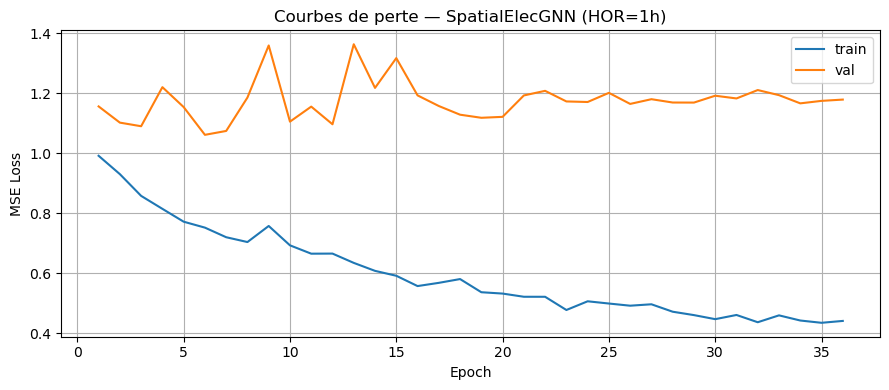

Best val_loss = 1.061068  (epoch 36)


In [143]:
# ============================================================
# Cellule 22 - Courbes d'apprentissage
# ============================================================
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_ran, history["train_loss"], label="train")
ax.plot(epochs_ran, history["val_loss"],   label="val")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Courbes de perte — SpatialElecGNN (HOR=1h)")
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()
print(f"Best val_loss = {early_stopper.best_loss:.6f}  (epoch {len(history['train_loss'])})")


In [144]:
# ============================================================
# Cellule 23 - Collecte des prédictions (train / val / test)
# ============================================================
def ensure_3d(arr: np.ndarray) -> np.ndarray:
    """[B*N_GEN, HOR] ou [B, N_GEN, HOR] → [B, N_GEN, HOR]."""
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == N_GEN and arr.shape[2] == HOR
        return arr
    assert arr.ndim == 2 and arr.shape[1] == HOR and arr.shape[0] % N_GEN == 0
    return arr.reshape(arr.shape[0] // N_GEN, N_GEN, HOR)

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    preds_scaled, trues_scaled, preds_real, trues_real, metas = [], [], [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        pred  = model(batch.x, batch.edge_index, batch.edge_attr, batch.generator_mask)
        y_true = batch.y
        pn = pred.detach().cpu().numpy()
        tn = y_true.detach().cpu().numpy()
        preds_scaled.append(pn); trues_scaled.append(tn)
        preds_real.append(inverse_targets(pn))
        trues_real.append(inverse_targets(tn))
        if hasattr(batch, "target_start_idx"):
            metas.append(batch.target_start_idx.detach().cpu().numpy())

    return {
        "preds_scaled": np.concatenate(preds_scaled),
        "trues_scaled": np.concatenate(trues_scaled),
        "preds_real"  : np.concatenate(preds_real),
        "trues_real"  : np.concatenate(trues_real),
        "metas"       : np.concatenate(metas) if metas else np.array([]),
    }

train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)

print("train preds_real.shape =", train_out["preds_real"].shape)
print("val   preds_real.shape =", val_out["preds_real"].shape)
print("test  preds_real.shape =", test_out["preds_real"].shape)


train preds_real.shape = (4065, 1)
val   preds_real.shape = (465, 1)
test  preds_real.shape = (915, 1)


In [145]:
# ============================================================
# Cellule 24 - Baseline persistance (same_hour_yesterday)
# ============================================================
def compute_persistence_split(dataset):
    preds, trues = [], []
    for start_idx in dataset.start_indices:
        start_idx = int(start_idx)
        pred = persistence_forecast_for_sample(start_idx)         # [N_GEN, 1]
        true = p_bus_generator[start_idx + HIST : start_idx + HIST + HOR].T  # [N_GEN, 1]
        preds.append(pred); trues.append(true)
    return np.stack(preds), np.stack(trues)   # [N, N_GEN, HOR]

pers_train_pred, pers_train_true = compute_persistence_split(train_ds)
pers_val_pred,   pers_val_true   = compute_persistence_split(val_ds)
pers_test_pred,  pers_test_true  = compute_persistence_split(test_ds)

print("pers_test_pred.shape =", pers_test_pred.shape)


pers_test_pred.shape = (61, 15, 1)


In [146]:
# ============================================================
# Cellule 25 - Métriques finales
# ============================================================
def evaluate_model(out, split_name, model_label="SpatialElecGNN"):
    p3 = ensure_3d(out["preds_real"])   # [B, N_GEN, 1]
    t3 = ensure_3d(out["trues_real"])
    rows = []
    # Global
    m = mae_rmse_nmae(t3, p3); m.update({"split": split_name, "model": model_label, "bus": "global"}); rows.append(m)
    # Par bus générateur
    for j, bus_idx in enumerate(CONFIG["GENERATOR_BUS_IDX"]):
        m = mae_rmse_nmae(t3[:, j, :], p3[:, j, :])
        m.update({"split": split_name, "model": model_label,
                  "bus": f"bus_{bus_idx}", "bus_name": buses_df.iloc[bus_idx]["Name"]})
        rows.append(m)
    return pd.DataFrame(rows)

def evaluate_persistence(pred, true, split_name):
    p3 = ensure_3d(pred) if pred.ndim == 3 else pred.reshape(pred.shape[0], N_GEN, HOR)
    t3 = ensure_3d(true) if true.ndim == 3 else true.reshape(true.shape[0], N_GEN, HOR)
    rows = []
    m = mae_rmse_nmae(t3, p3); m.update({"split": split_name, "model": "Persistence", "bus": "global"}); rows.append(m)
    for j, bus_idx in enumerate(CONFIG["GENERATOR_BUS_IDX"]):
        m = mae_rmse_nmae(t3[:, j, :], p3[:, j, :])
        m.update({"split": split_name, "model": "Persistence",
                  "bus": f"bus_{bus_idx}", "bus_name": buses_df.iloc[bus_idx]["Name"]})
        rows.append(m)
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    evaluate_model(train_out, "train"),
    evaluate_model(val_out,   "val"),
    evaluate_model(test_out,  "test"),
    evaluate_persistence(pers_train_pred, pers_train_true, "train"),
    evaluate_persistence(pers_val_pred,   pers_val_true,   "val"),
    evaluate_persistence(pers_test_pred,  pers_test_true,  "test"),
], ignore_index=True)

print("=== Résumé TEST — métriques globales ===")
display(
    metrics_df[
        (metrics_df["split"] == "test") & (metrics_df["bus"] == "global")
    ][["model", "MAE", "RMSE", "NMAE"]].reset_index(drop=True)
)

print("\n=== Résumé TEST — par bus générateur (SpatialElecGNN) ===")
display(
    metrics_df[
        (metrics_df["split"] == "test") &
        (metrics_df["model"] == "SpatialElecGNN") &
        (metrics_df["bus"] != "global")
    ][["bus", "bus_name", "MAE", "RMSE", "NMAE"]].reset_index(drop=True)
)


=== Résumé TEST — métriques globales ===


,model,MAE,RMSE,NMAE
0,SpatialElecGNN,1.651268,2.700422,0.408400
1,Persistence,0.865790,2.056739,0.214132



=== Résumé TEST — par bus générateur (SpatialElecGNN) ===


,bus,bus_name,MAE,RMSE,NMAE
0,bus_6,BRUEG,0.150087,0.198647,1.055060
1,bus_12,DOEL,4.896883,5.450052,0.331765
2,bus_14,GEZEL,1.733093,2.447440,1.077783
3,bus_15,GOUY,2.794655,3.815676,0.294667
4,bus_18,IZGEM,0.021298,0.056209,1.299190
5,bus_26,MEERH,0.789384,1.140235,0.205256
6,bus_27,MEKI+,1.395857,1.786865,0.594921
7,bus_28,MERCA,1.518845,2.247072,0.798928
8,bus_32,RODE+,1.313837,1.799464,0.406326
9,bus_35,SERAI,2.340077,2.905168,0.812493


In [147]:
# ============================================================
# Cellule — Métriques agrégées sur TEST
# Compatible avec ton notebook elec 1h
# ============================================================
import numpy as np
import pandas as pd

def compute_aggregated_metrics(y_true, y_pred, label="SpatialElecGNN", split="test"):
    """
    y_true, y_pred attendus sous forme :
    - [B*N_GEN, HOR]
    - ou [B, N_GEN, HOR]

    On agrège en sommant sur les générateurs :
    -> série agrégée de shape [B, HOR]
    """
    t3 = ensure_3d(y_true)   # [B, N_GEN, HOR]
    p3 = ensure_3d(y_pred)   # [B, N_GEN, HOR]

    # Somme sur les générateurs
    t_agg = t3.sum(axis=1)   # [B, HOR]
    p_agg = p3.sum(axis=1)   # [B, HOR]

    m = mae_rmse_nmae(t_agg, p_agg)
    m.update({
        "split": split,
        "model": label,
        "bus": "aggregated_total",
        "bus_name": "sum_all_generator_buses"
    })
    return pd.DataFrame([m])

# ------------------------------------------------------------
# SpatialElecGNN — TEST agrégé
# ------------------------------------------------------------
agg_gnn_test_df = compute_aggregated_metrics(
    test_out["trues_real"],
    test_out["preds_real"],
    label="SpatialElecGNN",
    split="test"
)

# ------------------------------------------------------------
# Persistence — TEST agrégé
# ------------------------------------------------------------
agg_pers_test_df = compute_aggregated_metrics(
    pers_test_true,
    pers_test_pred,
    label="Persistence",
    split="test"
)

# ------------------------------------------------------------
# Résumé
# ------------------------------------------------------------
agg_test_metrics_df = pd.concat(
    [agg_gnn_test_df, agg_pers_test_df],
    ignore_index=True
)

print("=== TEST — métriques agrégées (somme de tous les bus générateurs) ===")
display(agg_test_metrics_df[["model", "MAE", "RMSE", "NMAE"]])

# ------------------------------------------------------------
# Optionnel : séries agrégées pour analyses futures
# ------------------------------------------------------------
t3_test = ensure_3d(test_out["trues_real"])
p3_test = ensure_3d(test_out["preds_real"])

test_true_agg = t3_test.sum(axis=1)   # [B, HOR]
test_pred_agg = p3_test.sum(axis=1)   # [B, HOR]

print("Shapes agrégées :")
print("test_true_agg :", test_true_agg.shape)
print("test_pred_agg :", test_pred_agg.shape)

=== TEST — métriques agrégées (somme de tous les bus générateurs) ===


,model,MAE,RMSE,NMAE
0,SpatialElecGNN,4.645034,5.927497,0.076589
1,Persistence,10.981263,14.212967,0.181063


Shapes agrégées :
test_true_agg : (61, 1)
test_pred_agg : (61, 1)


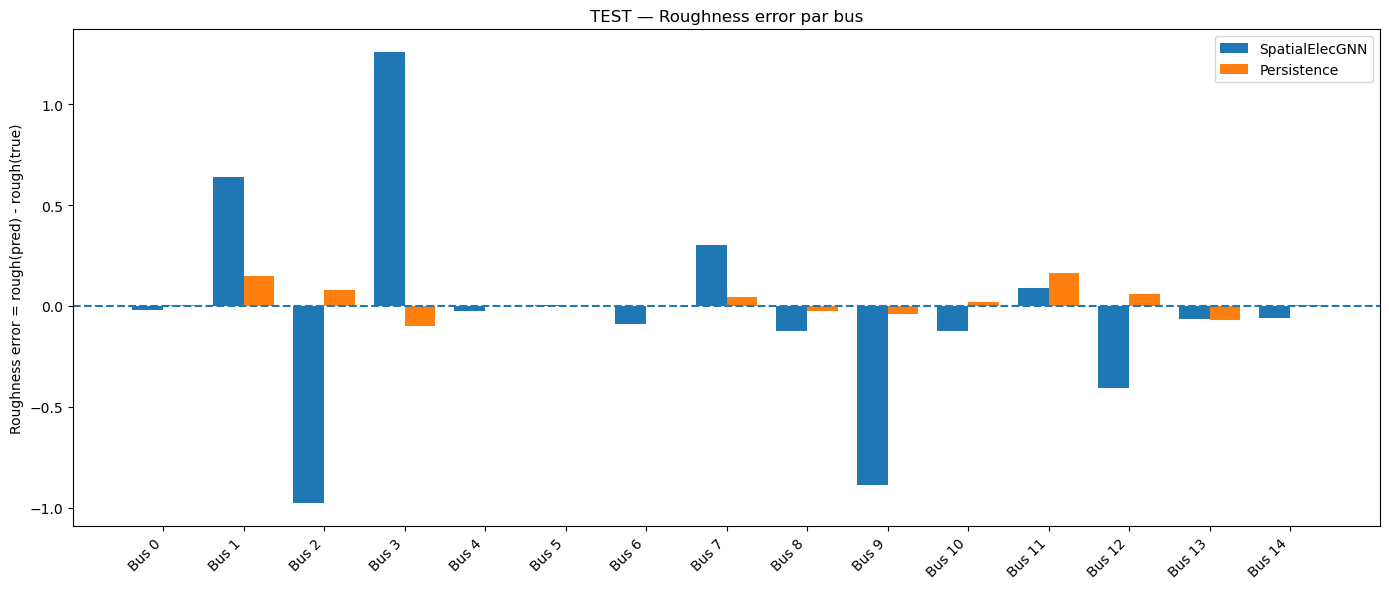

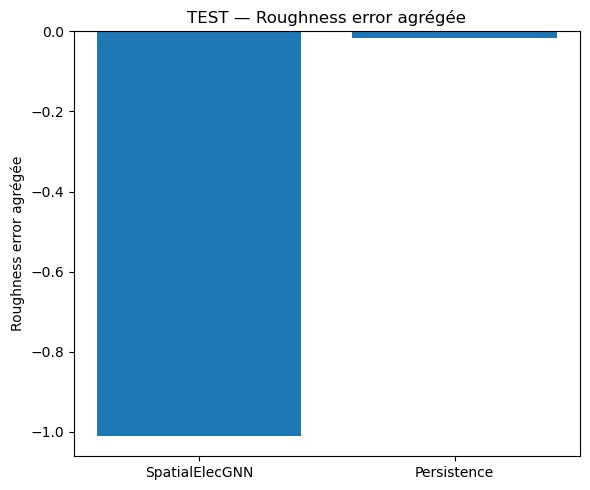

=== Roughness agrégée ===
SpatialElecGNN | rough(true)=11.108496 | rough(pred)=10.098376 | error=-1.010119
Persistence    | rough(true)=11.108494 | rough(pred)=11.092204 | error=-0.016290


In [148]:
# ============================================================
# Cellule — Plot roughness error sur TEST
# Compatible avec ton notebook elec 1h
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def roughness_series(x):
    """
    x : array [T]
    retourne la roughness d'une série 1D
    """
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return np.nan
    return float(np.mean(np.abs(np.diff(x))))

def compute_roughness_errors(y_true, y_pred):
    """
    y_true, y_pred :
    - soit [B*N_GEN, HOR]
    - soit [B, N_GEN, HOR]

    Retourne :
    - rough_true_by_bus : [N_GEN]
    - rough_pred_by_bus : [N_GEN]
    - rough_err_by_bus  : [N_GEN]
    - rough_true_agg    : scalaire
    - rough_pred_agg    : scalaire
    - rough_err_agg     : scalaire
    """
    t3 = ensure_3d(y_true)   # [B, N_GEN, HOR]
    p3 = ensure_3d(y_pred)   # [B, N_GEN, HOR]

    B, N_GEN, HOR = t3.shape

    # --------------------------------------------------------
    # Roughness par bus/générateur
    # On concatène tout le temps disponible pour chaque bus
    # --------------------------------------------------------
    rough_true_by_bus = []
    rough_pred_by_bus = []

    for g in range(N_GEN):
        true_g = t3[:, g, :].reshape(-1)
        pred_g = p3[:, g, :].reshape(-1)

        rough_true_by_bus.append(roughness_series(true_g))
        rough_pred_by_bus.append(roughness_series(pred_g))

    rough_true_by_bus = np.array(rough_true_by_bus)
    rough_pred_by_bus = np.array(rough_pred_by_bus)
    rough_err_by_bus  = rough_pred_by_bus - rough_true_by_bus

    # --------------------------------------------------------
    # Roughness agrégée
    # --------------------------------------------------------
    true_agg = t3.sum(axis=1).reshape(-1)   # somme sur les générateurs
    pred_agg = p3.sum(axis=1).reshape(-1)

    rough_true_agg = roughness_series(true_agg)
    rough_pred_agg = roughness_series(pred_agg)
    rough_err_agg  = rough_pred_agg - rough_true_agg

    return (
        rough_true_by_bus,
        rough_pred_by_bus,
        rough_err_by_bus,
        rough_true_agg,
        rough_pred_agg,
        rough_err_agg
    )

# ------------------------------------------------------------
# Calculs GNN
# ------------------------------------------------------------
(
    rough_true_gnn_bus,
    rough_pred_gnn_bus,
    rough_err_gnn_bus,
    rough_true_gnn_agg,
    rough_pred_gnn_agg,
    rough_err_gnn_agg
) = compute_roughness_errors(
    test_out["trues_real"],
    test_out["preds_real"]
)

# ------------------------------------------------------------
# Calculs Persistence
# ------------------------------------------------------------
(
    rough_true_pers_bus,
    rough_pred_pers_bus,
    rough_err_pers_bus,
    rough_true_pers_agg,
    rough_pred_pers_agg,
    rough_err_pers_agg
) = compute_roughness_errors(
    pers_test_true,
    pers_test_pred
)

# ------------------------------------------------------------
# Labels x
# ------------------------------------------------------------
if "bus_name" in metrics_df.columns:
    bus_labels = (
        metrics_df.loc[metrics_df["model"] == "SpatialElecGNN", "bus_name"]
        .drop_duplicates()
        .tolist()
    )
    if len(bus_labels) != len(rough_err_gnn_bus):
        bus_labels = [f"Bus {i}" for i in range(len(rough_err_gnn_bus))]
else:
    bus_labels = [f"Bus {i}" for i in range(len(rough_err_gnn_bus))]

x = np.arange(len(bus_labels))
width = 0.38

# ------------------------------------------------------------
# Plot 1 — Roughness error par bus
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.bar(x - width/2, rough_err_gnn_bus, width=width, label="SpatialElecGNN")
plt.bar(x + width/2, rough_err_pers_bus, width=width, label="Persistence")
plt.axhline(0.0, linestyle="--")
plt.xticks(x, bus_labels, rotation=45, ha="right")
plt.ylabel("Roughness error = rough(pred) - rough(true)")
plt.title("TEST — Roughness error par bus")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2 — Roughness agrégée
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
models = ["SpatialElecGNN", "Persistence"]
agg_vals = [rough_err_gnn_agg, rough_err_pers_agg]

plt.bar(models, agg_vals)
plt.axhline(0.0, linestyle="--")
plt.ylabel("Roughness error agrégée")
plt.title("TEST — Roughness error agrégée")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Prints utiles
# ------------------------------------------------------------
print("=== Roughness agrégée ===")
print(f"SpatialElecGNN | rough(true)={rough_true_gnn_agg:.6f} | rough(pred)={rough_pred_gnn_agg:.6f} | error={rough_err_gnn_agg:.6f}")
print(f"Persistence    | rough(true)={rough_true_pers_agg:.6f} | rough(pred)={rough_pred_pers_agg:.6f} | error={rough_err_pers_agg:.6f}")